<a href="https://colab.research.google.com/github/siddhi-308-dotcom/ML/blob/main/EXP4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving auto-mpg.csv to auto-mpg.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

In [4]:
df = pd.read_csv("auto-mpg.csv")
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


In [6]:
df.describe()

,mpg,cylinders,displacement,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


In [7]:
df.isnull().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model year,0
origin,0
car name,0


In [8]:
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
df['horsepower'].fillna(df['horsepower'].median(), inplace=True)

/tmp/ipykernel_171/1800950255.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['horsepower'].fillna(df['horsepower'].median(), inplace=True)


In [9]:
df = df.drop("car name", axis=1)

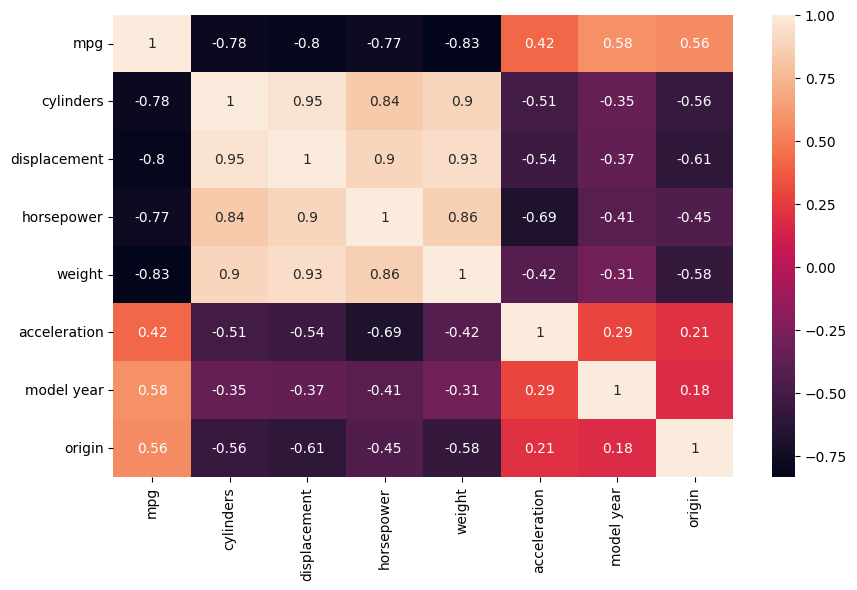

In [10]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True)
plt.show()

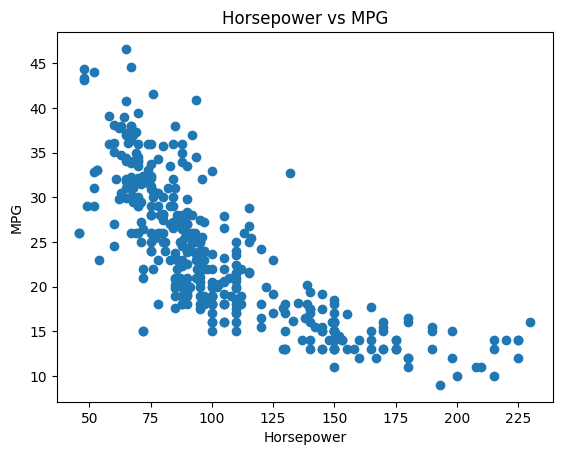

In [11]:
plt.scatter(df["horsepower"], df["mpg"])
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Horsepower vs MPG")
plt.show()

In [12]:
X = df.drop("mpg", axis=1)
y = df["mpg"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [15]:
pred = model.predict(X_test)

In [16]:
rmse = np.sqrt(mean_squared_error(y_test, pred))
print("Linear Regression RMSE:", rmse)

Linear Regression RMSE: 2.8631707748272697


In [18]:
poly = PolynomialFeatures(degree=2)

X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

In [19]:
poly_model = LinearRegression()
poly_model.fit(X_poly_train, y_train)

LinearRegression()

In [20]:
poly_pred = poly_model.predict(X_poly_test)

In [21]:
poly_rmse = np.sqrt(mean_squared_error(y_test, poly_pred))
print("Polynomial Regression RMSE:", poly_rmse)

Polynomial Regression RMSE: 2.4425886282537133


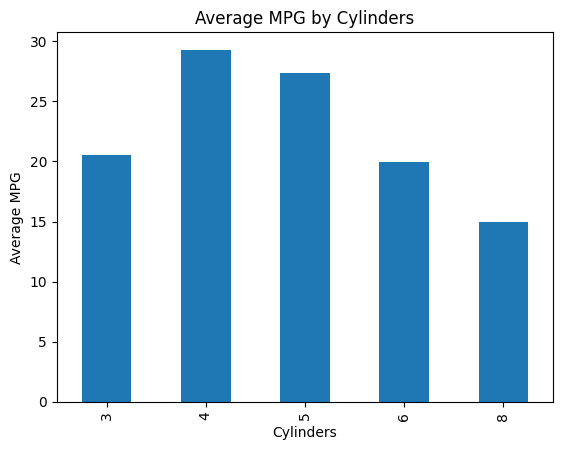

In [28]:
avg_mpg = df.groupby("cylinders")["mpg"].mean()

avg_mpg.plot(kind="bar")
plt.title("Average MPG by Cylinders")
plt.xlabel("Cylinders")
plt.ylabel("Average MPG")
plt.show()

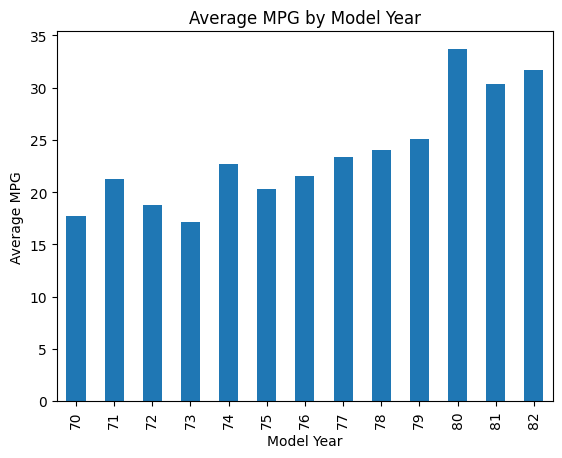

In [29]:
year_mpg = df.groupby("model year")["mpg"].mean()

year_mpg.plot(kind="bar")
plt.title("Average MPG by Model Year")
plt.xlabel("Model Year")
plt.ylabel("Average MPG")
plt.show()

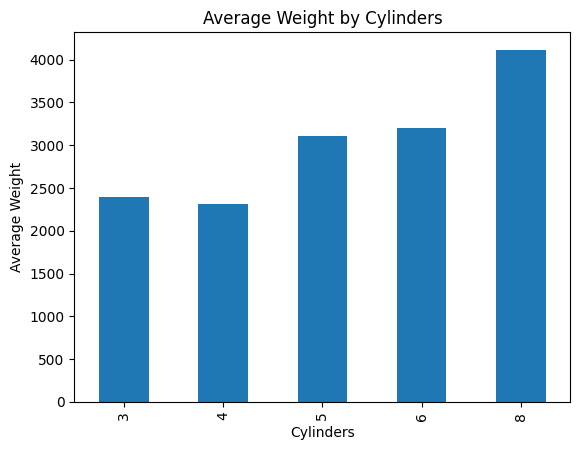

In [30]:
weight_cyl = df.groupby("cylinders")["weight"].mean()

weight_cyl.plot(kind="bar")
plt.title("Average Weight by Cylinders")
plt.xlabel("Cylinders")
plt.ylabel("Average Weight")
plt.show()

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Features and target
X = df.drop("mpg", axis=1)
y = df["mpg"]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Score
linear_score = linear_model.score(X_test, y_test)

print("Linear Regression Score:", linear_score)

Linear Regression Score: 0.8475304239212402


In [33]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)

X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_poly_train, y_train)

poly_score = poly_model.score(X_poly_test, y_test)

print("Polynomial Regression Score:", poly_score)

Polynomial Regression Score: 0.889034148611059


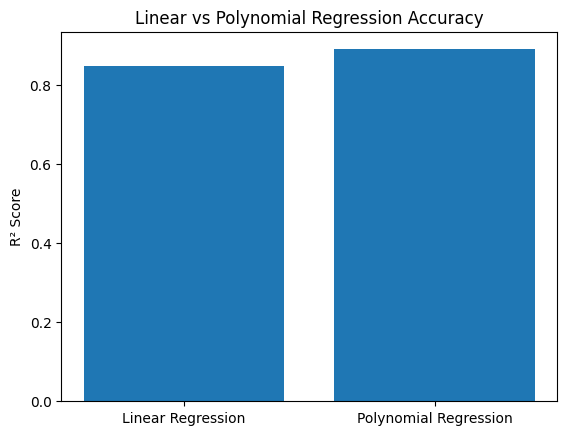

In [34]:
models = ["Linear Regression", "Polynomial Regression"]
scores = [linear_score, poly_score]

plt.bar(models, scores)
plt.title("Linear vs Polynomial Regression Accuracy")
plt.ylabel("R² Score")
plt.show()